# Chronos-2 — Fused RoPE+Attention Transform

Applies the `fused_rope_time_attention_transform_pass` MASE transform to Chronos-2,
then evaluates the result on the FEV benchmark against the unmodified baseline.

**What this notebook does:**
1. Loads the pretrained Chronos-2 model
2. Builds dummy inputs and traces into a `MaseGraph`
3. Applies the fused RoPE+attention transform (swaps each `TimeSelfAttention` inner `MHA` with `RoPEFusedMHA`)
4. Benchmarks latency: baseline model vs fused graph model
5. Evaluates both models on the FEV benchmark

The pass fuses RoPE rotation in-register inside the Triton attention kernel — rotated Q/K are never written to global memory.

## 1. Imports & config

In [1]:
import os
import statistics
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
os.environ.setdefault('HOME', os.environ.get('USERPROFILE', str(Path.home())))

import torch

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 2
OUTPUT_DIR = Path('artifacts/rope_fused')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}')
print(f'Batch size: {BATCH_SIZE}')

Device: cuda
Batch size: 2


## 2. Load Chronos-2 model

In [2]:
from chop.models import get_model

model = get_model('chronos-2', pretrained=True)
model.eval()
model = model.to(DEVICE)

# Force eager attention so FX can trace matmul/add/softmax nodes
if hasattr(model.config, '_attn_implementation'):
    model.config._attn_implementation = 'eager'

chronos_cfg = model.config.chronos_config
C_LEN       = chronos_cfg['context_length']    # e.g. 8192
OUT_PATCH   = chronos_cfg['output_patch_size'] # e.g. 16
N_VARIATES  = 20

print('Model loaded:', type(model).__name__)
print('Context length:', C_LEN)
print('Output patch size:', OUT_PATCH)
print('\nChronos config:')
for k, v in chronos_cfg.items():
    print(f'  {k}: {v}')

Model loaded: Chronos2Model
Context length: 8192
Output patch size: 16

Chronos config:
  context_length: 8192
  input_patch_size: 16
  input_patch_stride: 16
  max_output_patches: 64
  output_patch_size: 16
  quantiles: [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
  time_encoding_scale: 8192
  use_arcsinh: True
  use_reg_token: True


## 3. Build dummy inputs

- `context` — the historical time series values `(batch, context_length)` where batch = n_variates
- `group_ids` — which series in the batch share information via group attention.
  `zeros` puts everything in group 0 (fully multivariate), exercising the full group attention path.
  `arange` would make every series independent (diagonal mask, no cross-series mixing).
- `future_covariates` — known future values; `NaN` means no known future (pure forecast target)
- `num_output_patches` — how many output patches to predict

In [3]:
dummy_in = {
    'context':            torch.randn((N_VARIATES, C_LEN), device=DEVICE),
    'group_ids':          torch.zeros((N_VARIATES,), dtype=torch.long, device=DEVICE),
    # 'future_covariates':  torch.zeros((N_VARIATES, OUT_PATCH), device=DEVICE),
    'num_output_patches': OUT_PATCH,
}

In [4]:
print(model.encoder.block[0])

Chronos2EncoderBlock(
  (layer): ModuleList(
    (0): TimeSelfAttention(
      (self_attention): MHA(
        (q): Linear(in_features=768, out_features=768, bias=False)
        (k): Linear(in_features=768, out_features=768, bias=False)
        (v): Linear(in_features=768, out_features=768, bias=False)
        (o): Linear(in_features=768, out_features=768, bias=False)
        (rope_embed): RoPE()
      )
      (layer_norm): Chronos2LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): GroupSelfAttention(
      (self_attention): MHA(
        (q): Linear(in_features=768, out_features=768, bias=False)
        (k): Linear(in_features=768, out_features=768, bias=False)
        (v): Linear(in_features=768, out_features=768, bias=False)
        (o): Linear(in_features=768, out_features=768, bias=False)
      )
      (layer_norm): Chronos2LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): FeedForward(
      (mlp): MLP(
        (wi): Linear(in_features=

## 3b. Dummy input cases

Different `group_ids` / `future_covariates` combinations exercise different model paths:

| Case | `group_ids` | `future_covariates` | What it represents |
|---|---|---|---|
| `univariate` | `arange` (all unique) | NaN | Every series forecast independently — no cross-series attention |
| `multivariate` | all zeros | NaN | All series in one group — full cross-series attention |
| `mixed` | half-half | NaN | Two groups of equal size — partial cross-series mixing |
| `with_covariates` | all zeros | alternating NaN / real | Half the batch are known covariates, half are targets |

In [5]:
dummy_cases = {
    'univariate': {
        'context':            torch.randn((N_VARIATES, C_LEN), device=DEVICE),
        'group_ids':          torch.arange(N_VARIATES, dtype=torch.long, device=DEVICE),
        'num_output_patches': OUT_PATCH,
    },
    'multivariate': {
        'context':            torch.randn((N_VARIATES, C_LEN), device=DEVICE),
        'group_ids':          torch.zeros(N_VARIATES, dtype=torch.long, device=DEVICE),
        'num_output_patches': OUT_PATCH,
    },
    'mixed': {
        'context':            torch.randn((N_VARIATES, C_LEN), device=DEVICE),
        'group_ids':          torch.cat([
                                  torch.zeros(N_VARIATES // 2, dtype=torch.long),
                                  torch.ones(N_VARIATES // 2, dtype=torch.long),
                              ]).to(DEVICE),
        'num_output_patches': OUT_PATCH,
    },
}

## 4. Build MaseGraph

In [6]:

from chop import MaseGraph
from chop.passes.graph import PASSES
from chop.models.chronos2.layers import GroupSelfAttention, TimeSelfAttention

mg = MaseGraph(
    model=model,
    hf_input_names=list(dummy_in.keys()),
    custom_ops={
        'modules': {
            TimeSelfAttention: {
                'args': {
                    'hidden_states':    'data_in',
                    'attention_mask':   'data_in',
                    'position_ids':     'data_in',
                    'output_attentions': 'config',
                }
            },
            GroupSelfAttention: {
                'args': {
                    'hidden_states':    'data_in',
                    'attention_mask':   'data_in',
                    'output_attentions': 'config',
                }
            },
        },
        'functions': {}
    }
)

mg, _ = PASSES['init_metadata'](mg)
mg, _ = PASSES['add_common_metadata'](mg, pass_args={'dummy_in': dummy_in})

print(f'Graph nodes: {sum(1 for _ in mg.nodes)}')


`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
W0324 12:14:35.234000 1334 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


tensor([[-1.4038,  1.5976,  1.4476,  ..., -1.4391,  1.4923, -0.4077],
        [-0.1547, -0.5963, -0.5637,  ...,  0.7292, -0.6875, -1.7545],
        [-2.1492, -0.9205,  0.7881,  ..., -0.1682, -1.0876,  0.4942],
        ...,
        [ 0.0590,  1.1277,  0.6316,  ..., -1.3433,  1.9026,  1.3469],
        [-0.4901, -0.1754, -1.7996,  ...,  0.3805, -1.5324, -0.0376],
        [ 1.6431, -1.2955, -0.4701,  ..., -1.3679,  1.0034,  0.0463]], device='cuda:0')
tensor([[-1.4038,  1.5976,  1.4476,  ..., -1.4391,  1.4923, -0.4077],
        [-0.1547, -0.5963, -0.5637,  ...,  0.7292, -0.6875, -1.7545],
        [-2.1492, -0.9205,  0.7881,  ..., -0.1682, -1.0876,  0.4942],
        ...,
        [ 0.0590,  1.1277,  0.6316,  ..., -1.3433,  1.9026,  1.3469],
        [-0.4901, -0.1754, -1.7996,  ...,  0.3805, -1.5324, -0.0376],
        [ 1.6431, -1.2955, -0.4701,  ..., -1.3679,  1.0034,  0.0463]], device='cuda:0')
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., Fals

## 5. Fused RoPE+Attention Transform Pass

Swaps the inner `MHA` of every `TimeSelfAttention` block with `RoPEFusedMHA`.
The outer shell (layer norm, residual, dropout) is left completely untouched.

On CUDA with Triton available: RoPE is fused in-register during the tiled attention loop — rotated Q/K never leave registers.
On CPU or without Triton: a more efficient eager fallback is used (cos/sin computed once per forward, not re-expanded inside `RoPE.forward`).

In [7]:
from chop.passes.graph.transforms.timeseries import (
    fused_rope_time_attention_transform_pass,
    RoPETimeAttnAnalyser,
)
from chop.models.chronos2.triton_rope_attn import is_triton_available

print(f'Triton available: {is_triton_available()}')
print()

analysis = RoPETimeAttnAnalyser.analyse(mg)
print(f'TimeSelfAttention nodes found : {len(analysis)}')
print(f'  Eligible for fused RoPE     : {sum(1 for a in analysis if a.can_optimise)}')
for a in analysis:
    status = '✓' if a.can_optimise else '✗'
    print(f'  [{status}] {a.node_name:<40}  {a.reason}')

Triton available: True

TimeSelfAttention nodes found : 12
  Eligible for fused RoPE     : 12
  [✓] encoder_block_0_layer_0                   TimeSelfAttention with standard RoPE MHA detected
  [✓] encoder_block_1_layer_0                   TimeSelfAttention with standard RoPE MHA detected
  [✓] encoder_block_2_layer_0                   TimeSelfAttention with standard RoPE MHA detected
  [✓] encoder_block_3_layer_0                   TimeSelfAttention with standard RoPE MHA detected
  [✓] encoder_block_4_layer_0                   TimeSelfAttention with standard RoPE MHA detected
  [✓] encoder_block_5_layer_0                   TimeSelfAttention with standard RoPE MHA detected
  [✓] encoder_block_6_layer_0                   TimeSelfAttention with standard RoPE MHA detected
  [✓] encoder_block_7_layer_0                   TimeSelfAttention with standard RoPE MHA detected
  [✓] encoder_block_8_layer_0                   TimeSelfAttention with standard RoPE MHA detected
  [✓] encoder_block_9_la

In [8]:
mg, pass_info = fused_rope_time_attention_transform_pass(mg)

print(f'Modules replaced : {pass_info["replaced"]}')
print()
for a in pass_info['analysis']:
    status = 'replaced' if a.can_optimise else 'skipped '
    print(f'  [{status}] {a.module_path}')

Modules replaced : 12

  [replaced] encoder.block.0.layer.0
  [replaced] encoder.block.1.layer.0
  [replaced] encoder.block.2.layer.0
  [replaced] encoder.block.3.layer.0
  [replaced] encoder.block.4.layer.0
  [replaced] encoder.block.5.layer.0
  [replaced] encoder.block.6.layer.0
  [replaced] encoder.block.7.layer.0
  [replaced] encoder.block.8.layer.0
  [replaced] encoder.block.9.layer.0
  [replaced] encoder.block.10.layer.0
  [replaced] encoder.block.11.layer.0


## 6. Numerical sanity check

The fused model should produce the same `quantile_preds` as the original to within floating-point tolerance.

In [9]:
from chop.models.chronos2.modeling_chronos2 import Chronos2Output

mg.model.chronos_config = model.chronos_config

with torch.no_grad():
    orig_out  = model(**{k: v for k, v in dummy_in.items()})
    raw_fused = mg.model(**{k: v for k, v in dummy_in.items()})

# GraphModule returns a plain dict; convert to Chronos2Output for uniform access
fused_out = Chronos2Output(**raw_fused) if isinstance(raw_fused, dict) else raw_fused

max_diff = (orig_out.quantile_preds.float() - fused_out.quantile_preds.float()).abs().max().item()
close    = torch.allclose(orig_out.quantile_preds.float(), fused_out.quantile_preds.float(), atol=1e-3, rtol=1e-2)

print(f"Original output: {orig_out.quantile_preds.float()}")
print(f"Fused output   : {fused_out.quantile_preds.float()}")

print(f'Max abs diff in quantile_preds : {max_diff:.2e}')
print(f'Numerically close              : {"✓ YES" if close else "✗ NO — check kernel"}')


Original output: tensor([[[-2.4323, -2.4522, -2.4538,  ..., -2.3952, -2.3921, -2.3938],
         [-1.6843, -1.6965, -1.7019,  ..., -1.6639, -1.6623, -1.6735],
         [-1.3152, -1.3269, -1.3329,  ..., -1.3014, -1.3045, -1.3079],
         ...,
         [ 1.2701,  1.2523,  1.2526,  ...,  1.2258,  1.2127,  1.2220],
         [ 1.6055,  1.5860,  1.5975,  ...,  1.5609,  1.5515,  1.5627],
         [ 2.2305,  2.2052,  2.2387,  ...,  2.1994,  2.1944,  2.2213]],

        [[-2.4116, -2.4360, -2.4446,  ..., -2.3705, -2.3569, -2.3655],
         [-1.6564, -1.6715, -1.6798,  ..., -1.6272, -1.6169, -1.6303],
         [-1.2963, -1.3081, -1.3153,  ..., -1.2747, -1.2707, -1.2741],
         ...,
         [ 1.2587,  1.2363,  1.2404,  ...,  1.2189,  1.2087,  1.2153],
         [ 1.6163,  1.5892,  1.6013,  ...,  1.5796,  1.5714,  1.5788],
         [ 2.3291,  2.2898,  2.3208,  ...,  2.3127,  2.3045,  2.3258]],

        [[-2.4202, -2.4423, -2.4441,  ..., -2.3460, -2.3362, -2.3368],
         [-1.6421, -1.6598, 

## 7. Speed Benchmark

Compares the original model against the fused `mg.model` (fx.GraphModule) across the three dummy input cases.
Uses CUDA events for accurate GPU timing; `time.perf_counter` on CPU.

In [10]:
import time as _time

# Use a small fixed batch for benchmarking — N_VARIATES=20 × C_LEN=8192 makes
# each forward pass very slow, turning a latency measurement into a 10-min run.
BENCH_BATCH = 2
bench_cases = {
    name: {**inputs, 'context': inputs['context'][:BENCH_BATCH],
                     'group_ids': inputs['group_ids'][:BENCH_BATCH]}
    for name, inputs in dummy_cases.items()
}

def benchmark_model(fn, inputs: dict, warmup: int = 3, iters: int = 5, label: str = '') -> float:
    """Returns median latency in milliseconds. Uses CUDA events on GPU."""
    use_cuda = torch.cuda.is_available()
    if use_cuda:
        start = torch.cuda.Event(enable_timing=True)
        end   = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for i in range(warmup):
            fn(**inputs)
        if use_cuda:
            torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for i in range(iters):
            if use_cuda:
                start.record()
                fn(**inputs)
                end.record()
                torch.cuda.synchronize()
                t = start.elapsed_time(end)
            else:
                t0 = _time.perf_counter()
                fn(**inputs)
                t = (_time.perf_counter() - t0) * 1e3
            times.append(t)

    median = statistics.median(times)
    return median


print(f"{'case':<20} {'baseline (ms)':>14} {'fused (ms)':>12} {'speedup':>9}")
print('-' * 60)

bench_results = {}
for case_name, inputs in bench_cases.items():
    print(f'\n=== {case_name} ===')
    base_ms  = benchmark_model(model,    inputs, label='baseline')
    fused_ms = benchmark_model(mg.model, inputs, label='fused')
    bench_results[case_name] = {'baseline': base_ms, 'fused': fused_ms}
    print(f"{case_name:<20} {base_ms:>14.2f} {fused_ms:>12.2f} {base_ms/fused_ms:>8.3f}x")


case                  baseline (ms)   fused (ms)   speedup
------------------------------------------------------------

=== univariate ===
univariate                  2118.20      1510.98    1.402x

=== multivariate ===
multivariate                1801.42      1440.22    1.251x

=== mixed ===
mixed                       1799.74      1507.49    1.194x


## 8. FEV Benchmark Evaluation

Evaluates the fused model and the original baseline on three datasets from the Chronos FEV benchmark suite.
Results are collated with `fev.leaderboard` using the baseline as the reference.

In [18]:
import fev
import tqdm
from chronos import Chronos2Pipeline

# Attach model-level attributes needed by Chronos2Pipeline
setattr(mg.model, 'config',         model.config)
setattr(mg.model, 'chronos_config', model.chronos_config)
setattr(mg.model, 'device',         model.device)

tasks_configs = [
    {
        'dataset_path':   'autogluon/chronos_datasets',
        'dataset_config': 'monash_m1_quarterly',
        'horizon':        8,
        'seasonality':    4,
        'eval_metric':    'MASE',
    },
    {
        'dataset_path':   'autogluon/chronos_datasets',
        'dataset_config': 'monash_electricity_weekly',
        'horizon':        8,
        'num_windows':    2,
    },
    {
        'dataset_path':   'autogluon/chronos_datasets',
        'dataset_config': 'monash_m1_yearly',
        'horizon':        6,
    },
]
benchmark      = fev.Benchmark.from_list(tasks_configs)
summaries      = []
timing_records = []   # {'model', 'dataset_config', 'time_s'}

print(f'FEV tasks: {len(benchmark.tasks)}')


FEV tasks: 3


In [19]:
from chop.models.chronos2.modeling_chronos2 import Chronos2Output


class _FusedModelWrapper(torch.nn.Module):
    """Adapts the FX GraphModule to the Chronos2Forecasting forward API.

    The GraphModule was traced without ``future_covariates``, so its forward
    only accepts (context, group_ids, num_output_patches).  Chronos2Pipeline
    always passes ``future_covariates`` — as an all-NaN tensor for benchmark
    datasets that have no known future values.  All-NaN covariates carry zero
    information and are equivalent to ``future_covariates=None``, so dropping
    them is semantically correct for these tasks.

    The wrapper also boxes the dict returned by the GraphModule into a
    ``Chronos2Output`` so pipeline code can access ``.quantile_preds``.
    """

    def __init__(self, graph_module):
        super().__init__()
        self._inner        = graph_module
        self.config         = graph_module.config
        self.chronos_config = graph_module.chronos_config
        self.device         = graph_module.device

    def forward(self, context, group_ids=None, num_output_patches=1,
                future_covariates=None, **kwargs):
        result = self._inner(
            context=context,
            group_ids=group_ids,
            num_output_patches=num_output_patches,
        )
        return Chronos2Output(**result) if isinstance(result, dict) else result


# Evaluate fused model
fused_model    = _FusedModelWrapper(mg.model)
pipeline_fused = Chronos2Pipeline(model=fused_model)

for task in tqdm.tqdm(benchmark.tasks, desc='Evaluating fused RoPE model'):
    preds, t = pipeline_fused.predict_fev(task, batch_size=256)
    print(f'  [{task.dataset_config}] {t:.2f}s')
    summaries.append(task.evaluation_summary(preds, 'rope_fused_chronos2'))
    timing_records.append({'model': 'rope_fused_chronos2', 'dataset_config': task.dataset_config, 'time_s': t})


Evaluating fused RoPE model:  33%|███▎      | 1/3 [00:05<00:11,  5.88s/it]

  [monash_m1_quarterly] 4.16s


Evaluating fused RoPE model:  67%|██████▋   | 2/3 [00:22<00:12, 12.48s/it]

  [monash_electricity_weekly] 15.78s


Evaluating fused RoPE model: 100%|██████████| 3/3 [00:24<00:00,  8.19s/it]

  [monash_m1_yearly] 1.76s


In [20]:
# Evaluate baseline model
pipeline_baseline = Chronos2Pipeline(model=model)

for task in tqdm.tqdm(benchmark.tasks, desc='Evaluating baseline model'):
    preds, t = pipeline_baseline.predict_fev(task, batch_size=256)
    print(f'  [{task.dataset_config}] {t:.2f}s')
    summaries.append(task.evaluation_summary(preds, 'baseline_chronos2'))
    timing_records.append({'model': 'baseline_chronos2', 'dataset_config': task.dataset_config, 'time_s': t})


Evaluating baseline model:  33%|███▎      | 1/3 [00:04<00:09,  4.67s/it]

  [monash_m1_quarterly] 4.64s


Evaluating baseline model:  67%|██████▋   | 2/3 [00:21<00:11, 11.65s/it]

  [monash_electricity_weekly] 18.29s


Evaluating baseline model: 100%|██████████| 3/3 [00:24<00:00,  8.22s/it]

  [monash_m1_yearly] 3.44s


In [21]:
fev.leaderboard(summaries=summaries, baseline_model='baseline_chronos2')

,win_rate,skill_score,median_training_time_s,median_inference_time_s,training_corpus_overlap,num_failures
model_name,,,,,,
baseline_chronos2,0.5,0.0,NaN,NaN,0.0,0
rope_fused_chronos2,0.5,0.0,NaN,NaN,0.0,0


In [22]:
# Per-task error table
print(f"{'Model':<30} {'Dataset':<35} {'test_error':>12}")
print('-' * 80)
for s in sorted(summaries, key=lambda x: (x['dataset_config'], x['model_name'])):
    print(f"{s['model_name']:<30} {s['dataset_config']:<35} {s['test_error']:>12.4f}")

Model                          Dataset                               test_error
--------------------------------------------------------------------------------
baseline_chronos2              monash_electricity_weekly                 2.2293
rope_fused_chronos2            monash_electricity_weekly                 2.2293
baseline_chronos2              monash_m1_quarterly                       2.9557
rope_fused_chronos2            monash_m1_quarterly                       2.9557
baseline_chronos2              monash_m1_yearly                          7.3561
rope_fused_chronos2            monash_m1_yearly                          7.3561


In [23]:
# Inference time comparison: baseline vs fused
time_lookup = {(r['model'], r['dataset_config']): r['time_s'] for r in timing_records}
datasets    = list(dict.fromkeys(r['dataset_config'] for r in timing_records))

print(f"{'Dataset':<35} {'baseline (s)':>14} {'fused (s)':>12} {'speedup':>9}")
print('-' * 75)
total_base = total_fused = 0.0
for ds in datasets:
    base_t  = time_lookup.get(('baseline_chronos2',   ds), float('nan'))
    fused_t = time_lookup.get(('rope_fused_chronos2', ds), float('nan'))
    speedup = base_t / fused_t if fused_t > 0 else float('nan')
    total_base  += base_t
    total_fused += fused_t
    print(f"{ds:<35} {base_t:>14.2f} {fused_t:>12.2f} {speedup:>8.3f}x")
print('-' * 75)
print(f"{'TOTAL':<35} {total_base:>14.2f} {total_fused:>12.2f} {total_base/total_fused:>8.3f}x")


Dataset                               baseline (s)    fused (s)   speedup
---------------------------------------------------------------------------
monash_m1_quarterly                           4.64         4.16    1.116x
monash_electricity_weekly                    18.29        15.78    1.159x
monash_m1_yearly                              3.44         1.76    1.958x
---------------------------------------------------------------------------
TOTAL                                        26.37        21.70    1.215x


## 9. Scaling Performance Analysis

Synthetic sweep to characterise how latency and speedup scale with context length and batch size.
For each variate type (univariate / multivariate / mixed):

- **Sequence-length sweep**: context length ∈ `[256, 512, 1024, 2048, 4096]` at fixed batch size 4
- **Batch-size sweep**: batch size ∈ `[1, 2, 4, 8, 16]` at fixed context length 1 024

Each subplot overlays:
- **Solid / dashed lines** (left y-axis) — absolute latency in ms for baseline and fused model
- **Dotted line** (right y-axis) — speedup ratio (baseline / fused); values > 1 mean the fused model is faster


In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

SEQ_LENS    = [256, 512, 1024, 2048, 4096]
BATCH_SIZES = [1, 2, 4, 8, 16]
FIXED_SEQ   = 1024
FIXED_BATCH = 4
VARIATE_TYPES = ['univariate', 'multivariate', 'mixed']


def make_bench_inputs(variate_type: str, batch_size: int, seq_len: int) -> dict:
    ctx = torch.randn((batch_size, seq_len), device=DEVICE)
    if variate_type == 'univariate':
        gids = torch.arange(batch_size, dtype=torch.long, device=DEVICE)
    elif variate_type == 'multivariate':
        gids = torch.zeros(batch_size, dtype=torch.long, device=DEVICE)
    else:  # mixed
        half = max(1, batch_size // 2)
        gids = torch.cat([
            torch.zeros(half, dtype=torch.long),
            torch.ones(batch_size - half, dtype=torch.long),
        ]).to(DEVICE)
    return {'context': ctx, 'group_ids': gids, 'num_output_patches': OUT_PATCH}


# --- Sequence-length sweep (fixed batch size) ---
print(f'Sequence-length sweep  (batch={FIXED_BATCH})')
results_seq = {vt: {'baseline': [], 'fused': []} for vt in VARIATE_TYPES}
for seq_len in SEQ_LENS:
    print(f'  seq={seq_len:<5}', end='  ')
    for vt in VARIATE_TYPES:
        ins = make_bench_inputs(vt, FIXED_BATCH, seq_len)
        b = benchmark_model(model,    ins, warmup=2, iters=3)
        f = benchmark_model(mg.model, ins, warmup=2, iters=3)
        results_seq[vt]['baseline'].append(b)
        results_seq[vt]['fused'].append(f)
        print(f'{vt[:3]}={b/f:.2f}x', end='  ')
    print()

# --- Batch-size sweep (fixed sequence length) ---
print(f'\nBatch-size sweep  (seq={FIXED_SEQ})')
results_batch = {vt: {'baseline': [], 'fused': []} for vt in VARIATE_TYPES}
for bs in BATCH_SIZES:
    print(f'  batch={bs:<3}', end='  ')
    for vt in VARIATE_TYPES:
        ins = make_bench_inputs(vt, bs, FIXED_SEQ)
        b = benchmark_model(model,    ins, warmup=2, iters=3)
        f = benchmark_model(mg.model, ins, warmup=2, iters=3)
        results_batch[vt]['baseline'].append(b)
        results_batch[vt]['fused'].append(f)
        print(f'{vt[:3]}={b/f:.2f}x', end='  ')
    print()


Sequence-length sweep  (batch=4)
  seq=256    uni=1.04x  mul=0.98x  mix=1.09x  
  seq=512    uni=1.87x  mul=1.84x  mix=2.01x  
  seq=1024   uni=1.07x  mul=1.01x  mix=1.00x  
  seq=2048   uni=0.94x  mul=1.17x  mix=0.94x  
  seq=4096   uni=1.05x  mul=1.42x  mix=1.15x  

Batch-size sweep  (seq=1024)
  batch=1    uni=1.05x  mul=1.00x  mix=1.01x  
  batch=2    uni=2.19x  mul=2.19x  mix=1.82x  
  batch=4    uni=1.11x  mul=1.09x  mix=1.09x  
  batch=8    uni=0.87x  mul=1.01x  mix=0.88x  
  batch=16   uni=1.29x  mul=1.35x  mix=1.29x  


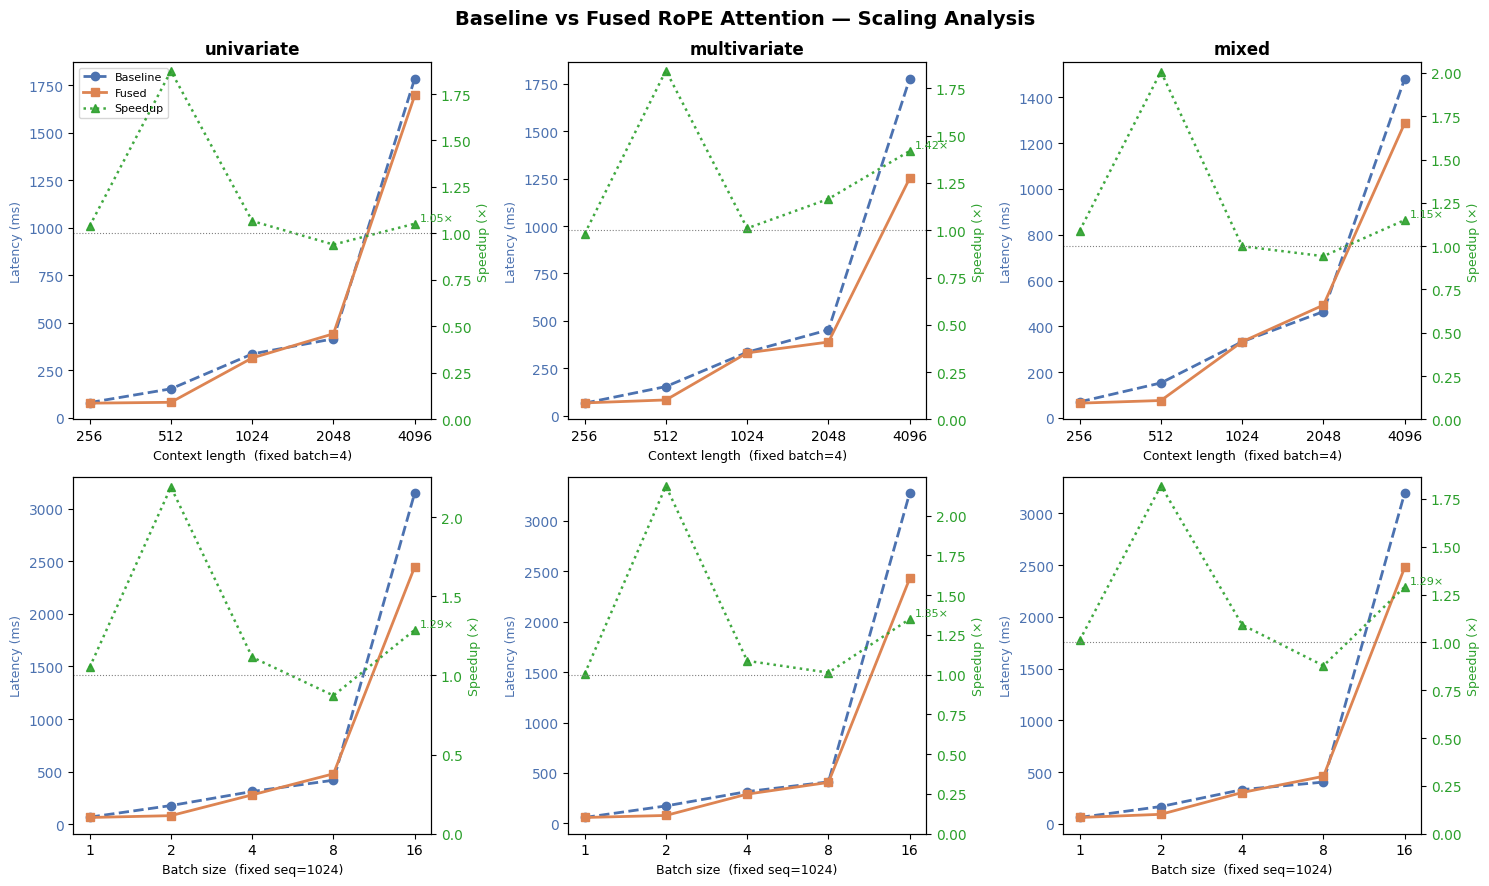

Saved → artifacts/rope_fused/scaling_analysis.png


In [25]:
BLUE   = '#4C72B0'   # baseline
ORANGE = '#DD8452'   # fused
GREEN  = '#2ca02c'   # speedup

sweep_rows = [
    (SEQ_LENS,    results_seq,   'Context length', f'(fixed batch={FIXED_BATCH})', True),
    (BATCH_SIZES, results_batch, 'Batch size',     f'(fixed seq={FIXED_SEQ})',     True),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Baseline vs Fused RoPE Attention — Scaling Analysis', fontsize=14, fontweight='bold')

for row_idx, (x_vals, results, x_label, x_note, use_log2) in enumerate(sweep_rows):
    for col_idx, vt in enumerate(VARIATE_TYPES):
        ax   = axes[row_idx, col_idx]
        ax2  = ax.twinx()

        base_ms  = np.array(results[vt]['baseline'])
        fused_ms = np.array(results[vt]['fused'])
        speedups = base_ms / fused_ms

        # Absolute latency lines
        ax.plot(x_vals, base_ms,  marker='o', linestyle='--', color=BLUE,   lw=2.0, label='Baseline')
        ax.plot(x_vals, fused_ms, marker='s', linestyle='-',  color=ORANGE, lw=2.0, label='Fused')

        # Speedup line on secondary axis
        ax2.plot(x_vals, speedups, marker='^', linestyle=':', color=GREEN, lw=1.8, alpha=0.9, label='Speedup')
        ax2.axhline(1.0, color='grey', lw=0.8, linestyle=':')

        # Titles and labels
        if row_idx == 0:
            ax.set_title(vt, fontsize=12, fontweight='bold')
        ax.set_xlabel(f'{x_label}  {x_note}', fontsize=9)
        ax.set_ylabel('Latency (ms)', fontsize=9, color=BLUE)
        ax2.set_ylabel('Speedup (×)', fontsize=9, color=GREEN)
        ax.tick_params(axis='y', labelcolor=BLUE)
        ax2.tick_params(axis='y', labelcolor=GREEN)
        ax2.set_ylim(bottom=0)

        # Annotate final speedup value
        ax2.annotate(f'{speedups[-1]:.2f}×',
                     xy=(x_vals[-1], speedups[-1]),
                     xytext=(4, 2), textcoords='offset points',
                     fontsize=8, color=GREEN)

        # Log-2 x-axis for power-of-2 values
        ax.set_xscale('log', base=2)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())
        ax.set_xticks(x_vals)

        # Unified legend in top-left subplot only
        if row_idx == 0 and col_idx == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.tight_layout()
save_path = OUTPUT_DIR / 'scaling_analysis.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_path}')
